HW #2 - Data Acquisition, Processing, and Communication

load data

In [24]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
import mapping
import SNOTEL_Analyzer
warnings.filterwarnings("ignore")

In [2]:
nldi = NLDI()
usgs_gage_id = "13042500" # NWIS id for Henry's Fork at the mouth of Island Park Reservoir
WY = 2025 # Water Year to analyze.

In [27]:
#get streamflow information using the NWIS id for the gage and ghte get_usgs_streamflow function in getData.py 
streamflow = getData.get_usgs_streamflow(usgs_gage_id)

NameError: name 'getData' is not defined

In [3]:
# put this in a seperate script eventually
basinname = 'IslandParkReservoir'
#Getting basin geometry
print('Collecting basins...', end='')
basin = nldi.get_basins(usgs_gage_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file(f"files/{basinname}.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{usgs_gage_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{usgs_gage_id}", "upstreamMain", "flowlines", distance=9999
)

In [17]:
# collect SNOTEL/SWE data

'''
Data pulled from: Gagliano, E. (2024).
snotel_ccss_stations (Version v1.0) [Computer software]. https://github.com/egagli/snotel_ccss_stations
'''
requested_sites = ['546_ID_SNTL', '860_ID_SNTL']
snotel_data = {}

for site in requested_sites:
    url = f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{site}.csv'
    try:
        snotel_data[site] = pd.read_csv(url)
        print(f"Loaded {site}: {len(snotel_data[site])} rows")
    except Exception as e:
        print(f"Error loading {site}: {e}")

# Quick preview of one loaded site
snotel_data['546_ID_SNTL'].head()

Loaded 546_ID_SNTL: 16251 rows
Loaded 860_ID_SNTL: 16251 rows


,datetime,TAVG,TMIN,TMAX,SNWD,WTEQ,PRCPSA
0,1981-10-01,NaN,NaN,NaN,NaN,0.0,0.0
1,1981-10-02,NaN,NaN,NaN,NaN,0.0,0.0
2,1981-10-03,NaN,NaN,NaN,NaN,0.0,0.0
3,1981-10-04,NaN,NaN,NaN,NaN,0.0,0.0
4,1981-10-05,NaN,NaN,NaN,NaN,0.0,0.0


In [14]:
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData'] == True]

# Keep only the two target SNOTEL stations
target_codes = {'546_ID_SNTL', '860_ID_SNTL'}
gdf_in_bbox = all_stations_gdf[all_stations_gdf.index.astype(str).isin(target_codes)].copy()

# Reset index to have site id as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

# Make begin and end date strings for folium serialization
gdf_in_bbox['beginDate'] = [datetime.datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0, len(gdf_in_bbox), 1)]
gdf_in_bbox['endDate'] = [datetime.datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0, len(gdf_in_bbox), 1)]
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,546_ID_SNTL,Island Park,SNOTEL,1917.192017,44.420300,-111.385117,Idaho,170402020601,12TVQ,None,1979-10-01,2026-03-29,True,POINT (-111.38512 44.4203)
1,860_ID_SNTL,White Elephant,SNOTEL,2350.008057,44.532669,-111.410851,Idaho,170402020305,12TVQ,Idaho-Bitterroot Rocky Mountains,1979-10-01,2026-03-29,True,POINT (-111.41085 44.53267)


In [6]:
# create map, having trouble showigng the map? Does "Make this Notebook Trusted to load map" appear?
#cd to the directy and run jupyter trust HW2.ipynb
import mapping
mapping.basin_mapping(basin, site_feature)
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

In [20]:
# Process SNOTEL data using data loaded in the collect-data cell
import importlib
import dataprocessing
importlib.reload(dataprocessing)

sites = list(gdf_in_bbox.code)
stateab = 'Id'
sitedict = {}

for site in sites:
    sitedf = snotel_data.get(site)
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab, WY, sitedf=sitedf)

# Show first processed site table
first_site = sites[0]
print(f"Processed site: {first_site}")
sitedict[first_site].head()

546_ID_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
860_ID_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
Processed site: 546_ID_SNTL


,M,D,1982_SWE_in,1983_SWE_in,1984_SWE_in,1985_SWE_in,1986_SWE_in,1987_SWE_in,1988_SWE_in,1989_SWE_in,...,2026_SWE_in,min,Q10,Q25,mean,median,Q75,Q90,max,date
M-D,,,,,,,,,,,,,,,,,,,,,
10-01,10,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0000,2023-10-01
10-02,10,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0000,2023-10-02
10-03,10,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000116,0.0,0.0,0.0,0.0051,2023-10-03
10-04,10,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0000,2023-10-04
10-05,10,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0000,2023-10-05


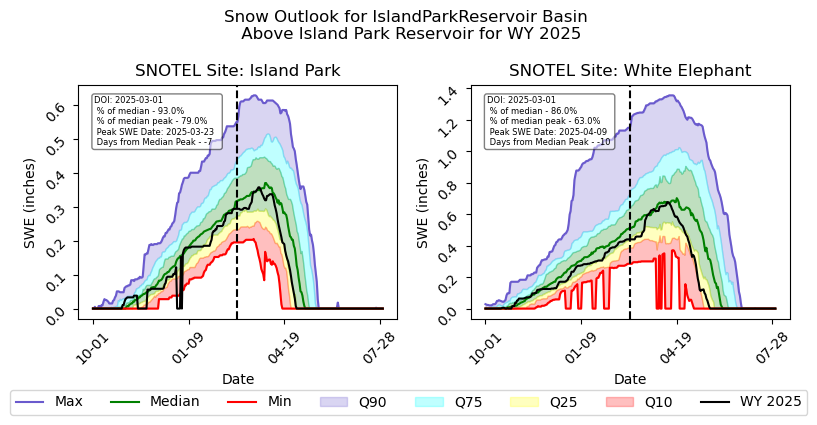

In [25]:
watershed = "IslandParkReservoir"
AOI = 'Above Island Park Reservoir'
DOI = '03-01' #must be in MM-DD form
SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_bbox, WY, watershed, AOI,DOI)